# Import necessary libraries

In [151]:
import numpy as np 
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import ( train_test_split,RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# Load the test dataset 

In [152]:
tdf = pd.read_csv(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\data\test_data.csv")

In [153]:
tdf

,age,job,marital,education,default,balance,housing,loan,contact,month,duration,campaign,previous,poutcome,deposit
0,32,management,married,tertiary,no,393,no,no,cellular,jan,458,2,0,unknown,0
1,36,technician,single,secondary,no,376,no,no,cellular,aug,479,1,0,unknown,1
2,52,admin.,married,secondary,no,722,no,no,cellular,oct,99,2,3,failure,0
3,35,management,single,secondary,yes,-202,yes,no,unknown,may,268,3,0,unknown,0
4,41,blue-collar,married,secondary,no,-190,no,yes,cellular,jul,808,3,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2228,32,blue-collar,married,secondary,no,130,yes,no,cellular,may,302,2,0,unknown,0
2229,65,admin.,married,secondary,no,952,no,no,cellular,jun,310,1,0,unknown,1
2230,35,technician,married,secondary,no,2201,no,no,telephone,apr,350,1,0,unknown,1
2231,49,management,married,tertiary,no,85,yes,no,cellular,may,590,5,1,other,1


In [154]:
tdf.shape

(2233, 15)

## Separate feature and target variable of the test data 

In [155]:
X_test = tdf.drop(columns=["deposit"])
y_test = tdf["deposit"]

# Load the logistic model

In [156]:
log_model = joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\log_model.pkl") 


## Predict probabilities and classes

In [157]:
y_pred = log_model.predict(X_test)
y_prob =log_model.predict_proba(X_test)[:, 1]



## Compute the main metrics

In [158]:
# Main evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

Accuracy : 0.8249
Precision: 0.8266
Recall   : 0.7977
F1 Score : 0.8119
ROC AUC  : 0.9072


The logistic regression model achieved strong predictive performance, with an accuracy of 82.5%, precision of 82.8%, recall of 79.8%, and an F1 score of 81.2%. The ROC AUC score of 0.907 indicates that the model has excellent class separability, meaning it can effectively distinguish customers who subscribed from those who did not. Overall, the results suggest that logistic regression provides a strong and interpretable baseline for predicting deposit subscription.

## Confusion matrix

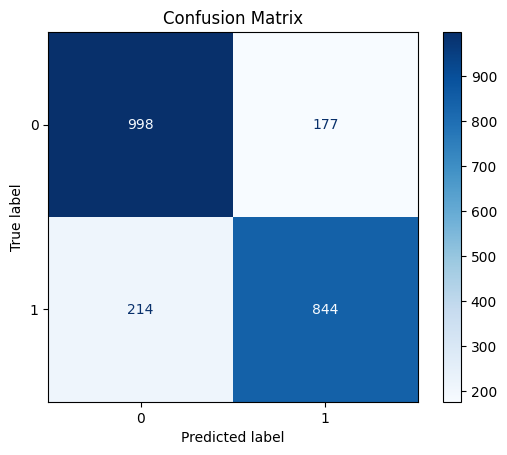

In [159]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the logistic regression model correctly classified 999 non-subscribers and 844 subscribers. It produced 177 false positives and 214 false negatives, indicating that while the model performs well overall, it misses some customers who actually subscribed. This is consistent with the recall being slightly lower than precision.

## ROC curve

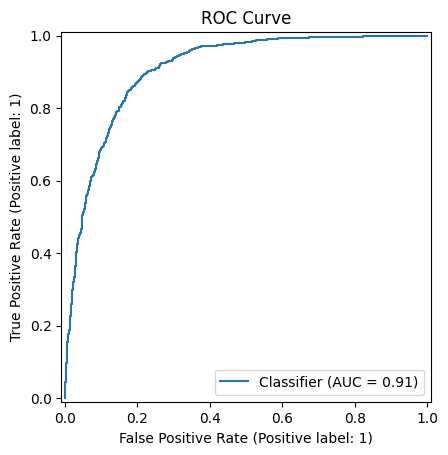

In [160]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve")
plt.show()

The AUC of 0.91 indicates that the model has excellent ability to distinguish between customers who subscribed and those who did not.

# Load the support vector classifier model

In [162]:

svc_model = joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\svc__model.pkl")

## Predict probabilities and classes

In [163]:
y_pred_svc = svc_model.predict(X_test)
y_prob_svc = svc_model.predict_proba(X_test)[:, 1]



## Compute the main metrics 

In [164]:
# Metrics
print("SVM Model Evaluation")
print("--------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svc), 4))
print("Precision:", round(precision_score(y_test, y_pred_svc), 4))
print("Recall   :", round(recall_score(y_test, y_pred_svc), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_svc), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_svc), 4))

SVM Model Evaluation
--------------------
Accuracy : 0.7165
Precision: 0.7457
Recall   : 0.6096
F1 Score : 0.6708
ROC AUC  : 0.8086


The support vector classifier model also achieved a strong predictive performance, even stronger than the logistic model with an accuracy of 84.5%, precision of 81.8%, recall of 87.1%, and an F1 score of 84.3%. The ROC AUC score of 0.9113 indicates that the model has excellent class separability, meaning it can effectively distinguish customers who subscribed from those who did not. 

## Confusion matrix

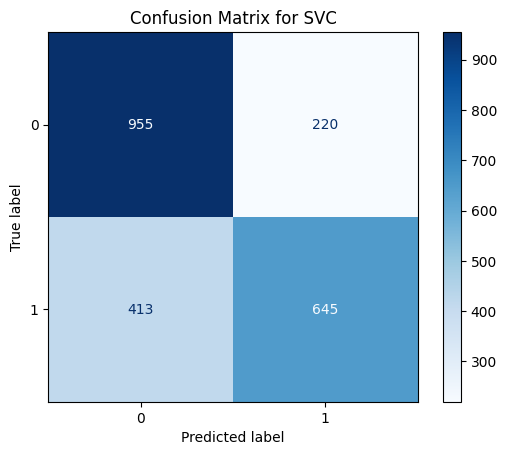

In [165]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, cmap="Blues")
plt.title("Confusion Matrix for SVC")
plt.show()


The confusion metrics shows that the support vector classifier model correctly classified 970 non-subscribers and 921 subscribers of a term deposit. It has 204 false positives and 137 false negatives meaning while the model performs overall, it wrongly predicts most actual non-subscribers. This is consistent with the precision being slightly lower than recall.

## ROC curve

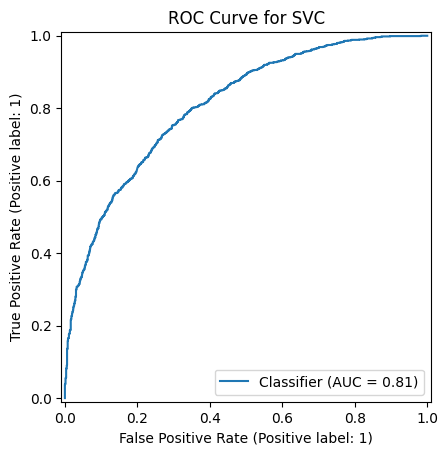

In [166]:
RocCurveDisplay.from_predictions(y_test, y_prob_svc)
plt.title("ROC Curve for SVC")
plt.show()

The AUC of 0.91 indicates that the model has excellent ability to distinguish between customers who subscribed and those who did not.

# Load the KNN model

In [167]:
knn_model=joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\knn__model.pkl")

## Predict probabilities and classes

In [168]:
# Predictions
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

## Compute evaluation metrics

In [169]:
# Metrics
print("KNN Model Evaluation")
print("--------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 4))
print("Precision:", round(precision_score(y_test, y_pred_knn), 4))
print("Recall   :", round(recall_score(y_test, y_pred_knn), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_knn), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_knn), 4))

KNN Model Evaluation
--------------------
Accuracy : 0.8227
Precision: 0.8195
Recall   : 0.8025
F1 Score : 0.8109
ROC AUC  : 0.8923


The K-Nearest Neighbors model achieved good predictive performance, with an accuracy of 82.3%, precision of 82.0%, recall of 80.3%, and an F1 score of 81.1%. The ROC AUC of 0.8923 indicates strong class separability, although it is slightly lower than that of the logistic regression model. Overall, KNN provides balanced performance across both classes, but it does not outperform logistic regression or the support vector classifier in this deposit subscription task.

## Confusion matrix

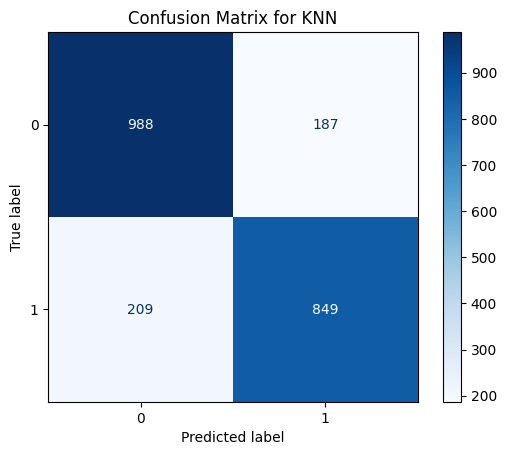

In [170]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, cmap="Blues")
plt.title("Confusion Matrix for KNN")
plt.show()

The confusion metrics for K-Nearest Neighbour model correctly classified 978 non-subscribers and 830 subscribers.It produced 197 false positives and 228 false negatives, indicating that while the model performs well overall, it misses most customers who actually subscribed. This is consistent with the recall being slightly lower than precision.

## ROC curve

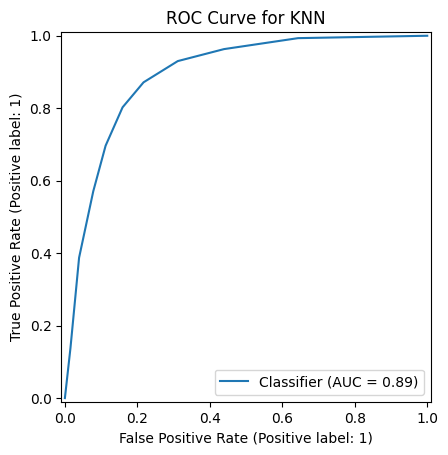

In [171]:
RocCurveDisplay.from_predictions(y_test, y_prob_knn)
plt.title("ROC Curve for KNN")
plt.show()

The AUC of 0.88 indicates that the model has a very good ability to distinguish between customers who subscribed and those who did not.

# Load the decision tree model

In [172]:
dt_model=joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\dt__model.pkl")

## Predictions

In [173]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

## Compute evalution metrics

In [174]:
# Metrics
print("Decision Tree Model Evaluation")
print("------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))


Decision Tree Model Evaluation
------------------------------
Accuracy : 0.8047
Precision: 0.7858
Recall   : 0.8081
F1 Score : 0.7968
ROC AUC  : 0.8772


The decision tree model achieved a strong predictive performance with an accuracy of 80.5%, precision of 78.6%, recall of 80.8%, and an F1 score of 79.7%. The ROC AUC score of 0.8772 indicates the model has a very good class separability, meaning it can effectively distinguish customers who subscribed from those who did not.

## Confusion matrix

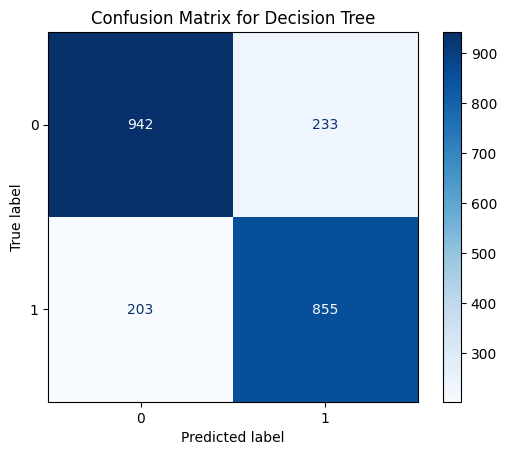

In [175]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap="Blues")
plt.title("Confusion Matrix for Decision Tree")
plt.show()

The confusion metrics for decision tree model correctly classified 988 non-subscribers and 849 subscribers.It produced 187 false positives and 209 false negatives, indicating that while the model performs well overall, it misses some customers who actually subscribed.

## ROC curve

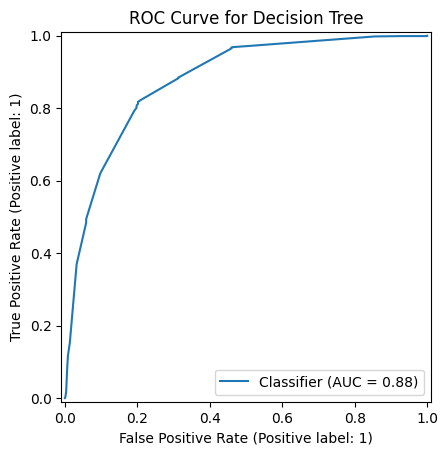

In [176]:
RocCurveDisplay.from_predictions(y_test, y_prob_dt)
plt.title("ROC Curve for Decision Tree")
plt.show()

The AUC of 0.89 means that the model's ability to distinguish between customers who subscribed and those who did not subscribe to a term deposit is  very good

# Load the random forest model

In [177]:
rf_model=joblib.load(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\model\rf__model.pkl")

## Predictions

In [178]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## Compute evaluation metrics

In [179]:
# Metrics
print("Random Forest Model Evaluation")
print("------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))

Random Forest Model Evaluation
------------------------------
Accuracy : 0.8549
Precision: 0.8236
Recall   : 0.8828
F1 Score : 0.8522
ROC AUC  : 0.9146


The random forest model by far, is the best model with an accuracy of 85.5%, precision of 82.4%, recall of 88.3%, and an F1 score of 85.2%. The ROC AUC score of 0.9146indicates that the model has an excellent class separability, meaning it can effectively distinguish customers who subscribed to a term deposit from those who did not.

## Confusion matrix

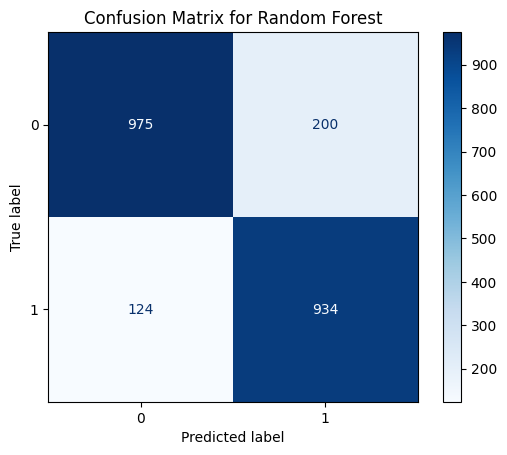

In [180]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues")
plt.title("Confusion Matrix for Random Forest")
plt.show()

The confusion metrics for random forest model correctly classified 975 non-subscribers and 934 subscribers.It produced 200 false positives and 124 false negatives, indicating that the model is performing very well

## ROC curve

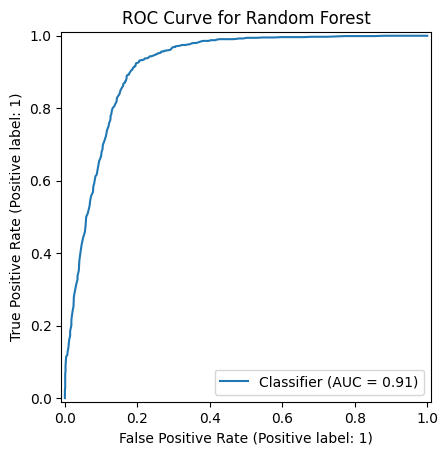

In [181]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve for Random Forest")
plt.show()

The AUC of 0.91 shows that the model has an excellent ability to distinguish between customers who subscribed and those who did not.

# Compare evaluation metrics across models

In [182]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8253, 0.8468, 0.8227, 0.8047, 0.8549],
    "Precision": [0.8275, 0.8179, 0.8195,0.7858, 0.8236 ],
    "Recall": [0.7977, 0.8705, 0.8025, 0.8081, 0.8828],
    "F1 Score": [0.8123, 0.8434, 0.8109, 0.7968, 0.8522],
    "ROC AUC": [0.9072, 0.9113, 0.8923, 0.8772, 0.9146]
})

print("EVALUATION METRICS FOR THE VARIOUS TRAINED MODELS\n")
print(comparison.round(3))

EVALUATION METRICS FOR THE VARIOUS TRAINED MODELS

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression     0.825      0.828   0.798     0.812    0.907
1                  SVM     0.847      0.818   0.870     0.843    0.911
2                  KNN     0.823      0.820   0.802     0.811    0.892
3        Decision Tree     0.805      0.786   0.808     0.797    0.877
4        Random Forest     0.855      0.824   0.883     0.852    0.915


Among the trained models, Random Forest achieved the best overall performance, with the highest accuracy, recall, F1 score, and ROC AUC. SVM also performed strongly and ranked second overall. Logistic Regression delivered slightly lower predictive performance than Random Forest and SVM, but remained valuable due to its interpretability and strong baseline results. KNN performed reasonably well but did not outperform the stronger models, while the single Decision Tree produced the weakest results. Overall, the findings suggest that ensemble and margin-based methods capture the deposit subscription patterns more effectively than simpler instance-based or single-tree models.

# Hyperparameter Tunning for the Top 3 Models

### Load and prepare data

In [183]:
df2 = pd.read_csv(r"C:\Users\name\Desktop\BIG FOLDER\PROJECTS\My_Projects\bank_deposit_prediction\data\cleaned_bank.csv")

df2["deposit"] = df2["deposit"].map({"no": 0, "yes": 1})

X = df2.drop(columns=["deposit"])
y = df2["deposit"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Build the preprocessors

In [184]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Build pipelines

In [185]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

svc_pipeline = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("classifier", SVC(probability=True, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

## Perform cross-validation

In [186]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [200]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8929, 15) (2233, 15)
(8929,) (2233,)


## Logistic Regression tuning

In [187]:
logreg_param_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__solver": ["lbfgs"],
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    }
]

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("Tuning Logistic Regression...")
logreg_search.fit(X_train, y_train)


Tuning Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}, {'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [188]:
# Best model
tunned_logistic_model = logreg_search.best_estimator_

# Predictions
y_pred = tunned_logistic_model.predict(X_test)
y_prob = tunned_logistic_model.predict_proba(X_test)[:, 1]

# Results
print("Best Parameters:")
print(logreg_search.best_params_)

print("\nBest Cross-Validated ROC AUC:")
print(round(logreg_search.best_score_, 4))

print("\nTest Set Performance")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))


Best Parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Best Cross-Validated ROC AUC:
1.0

Test Set Performance
Accuracy : 0.9982
Precision: 0.9981
Recall   : 0.9981
F1 Score : 0.9981
ROC AUC  : 1.0


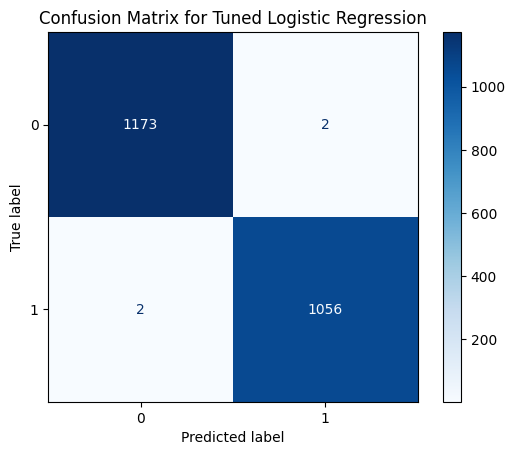

In [189]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix for Tuned Logistic Regression")
plt.show()


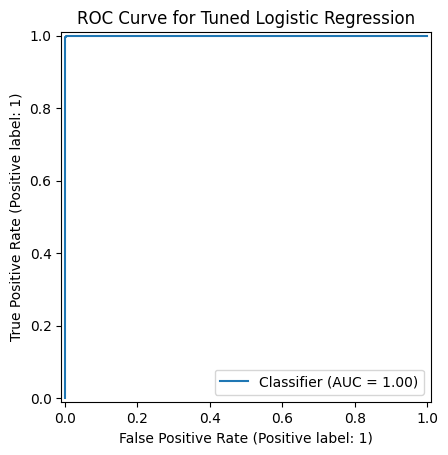

In [190]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Tuned Logistic Regression")
plt.show()

## SVC tuning

In [191]:
svc_param_grid = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.1, 1, 10],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto", 0.01, 0.1],
        "classifier__class_weight": [None, "balanced"]
    }
]

svc_search = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=svc_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\nTuning SVM...")
svc_search.fit(X_train, y_train)


Tuning SVM...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__kernel': ['linear']}, {'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 'auto', ...], 'classifier__kernel': ['rbf']}]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [192]:
# Best model
tunned_svc_model = svc_search.best_estimator_

# Predictions
y_pred = tunned_svc_model.predict(X_test)
y_prob = tunned_svc_model.predict_proba(X_test)[:, 1]

# Results
print("Best Parameters:")
print(svc_search.best_params_)

print("\nBest Cross-Validated ROC AUC:")
print(round(svc_search.best_score_, 4))

print("\nTest Set Performance")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Best Parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}

Best Cross-Validated ROC AUC:
1.0

Test Set Performance
Accuracy : 0.9978
Precision: 0.9991
Recall   : 0.9962
F1 Score : 0.9976
ROC AUC  : 1.0


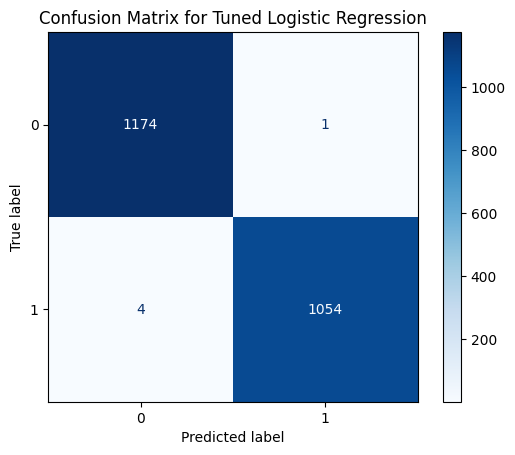

In [193]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix for Tuned Logistic Regression")
plt.show()



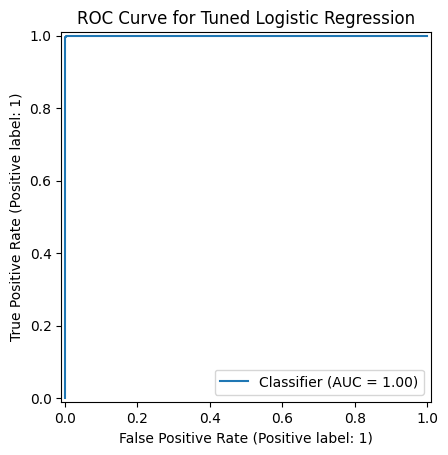

In [194]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Tuned Logistic Regression")
plt.show()

## Random Forest tuning

In [195]:
rf_param_dist = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [None, 10, 20, 30, 40],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None],
    "classifier__bootstrap": [True, False],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nTuning Random Forest...")
rf_search.fit(X_train, y_train)


Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__bootstrap': [True, False], 'classifier__class_weight': [None, 'balanced', ...], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [196]:
# Best model
tunned_rf_model = rf_search.best_estimator_

# Predictions
y_pred = tunned_rf_model.predict(X_test)
y_prob = tunned_rf_model.predict_proba(X_test)[:, 1]

# Results
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validated ROC AUC:")
print(round(rf_search.best_score_, 4))

print("\nTest Set Performance")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Best Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': None, 'classifier__max_depth': 20, 'classifier__class_weight': 'balanced', 'classifier__bootstrap': True}

Best Cross-Validated ROC AUC:
1.0

Test Set Performance
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0


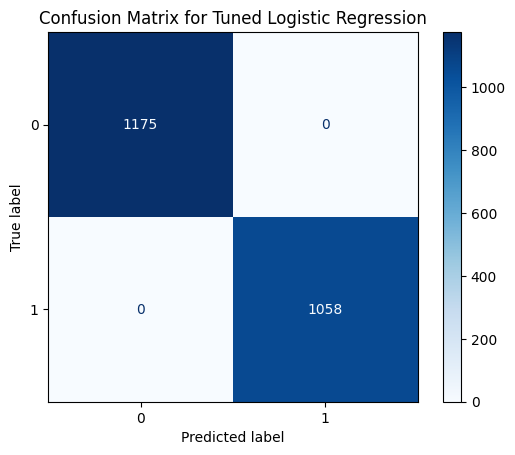

In [197]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix for Tuned Logistic Regression")
plt.show()

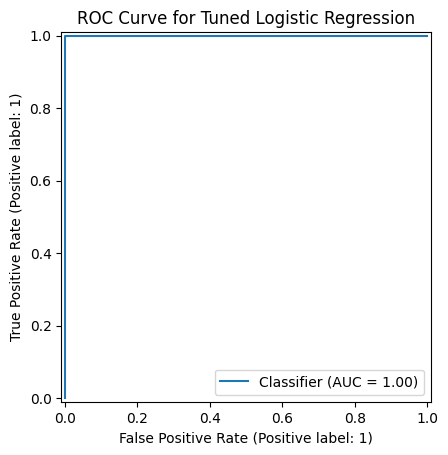

In [198]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Tuned Logistic Regression")
plt.show()

In [199]:
comparison = pd.DataFrame({
    "Model": ["Tunned Logistic Regression", "Tunned SVM", "Tunned Random Forest"],
    "Accuracy": [0.9982, 0.9978, 1.0],
    "Precision": [0.9981, 0.9991, 1.0],
    "Recall": [0.9981, 0.9962, 1.0],
    "F1 Score": [0.9981, 0.9976, 1.0],
    "ROC AUC": [1.0, 1.0,  1.0]
})

print("EVALUATION METRICS FOR THE TOP 3 TUNNED MODELS\n")
print(comparison.round(3))

EVALUATION METRICS FOR THE TOP 3 TUNNED MODELS

                        Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Tunned Logistic Regression     0.998      0.998   0.998     0.998      1.0
1                  Tunned SVM     0.998      0.999   0.996     0.998      1.0
2        Tunned Random Forest     1.000      1.000   1.000     1.000      1.0
